In [70]:
import pandas as pd
import numpy as np
import missingno

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [71]:
train = pd.read_csv("data/train.csv")

In [72]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [73]:
train.duplicated().sum()

np.int64(0)

In [74]:
train.dtypes.value_counts()

float64    6
str        5
object     2
bool       1
Name: count, dtype: int64

In [75]:
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Name            200
Cabin           199
VRDeck          188
Spa             183
FoodCourt       183
Destination     182
RoomService     181
Age             179
dtype: int64

In [76]:
missing_percent = (train.isnull().mean() * 100).sort_values(ascending=False)
missing_percent = missing_percent[missing_percent > 0]
missing_percent

CryoSleep       2.496261
ShoppingMall    2.392730
VIP             2.335212
HomePlanet      2.312205
Name            2.300702
Cabin           2.289198
VRDeck          2.162660
Spa             2.105142
FoodCourt       2.105142
Destination     2.093639
RoomService     2.082135
Age             2.059128
dtype: float64

<Axes: >

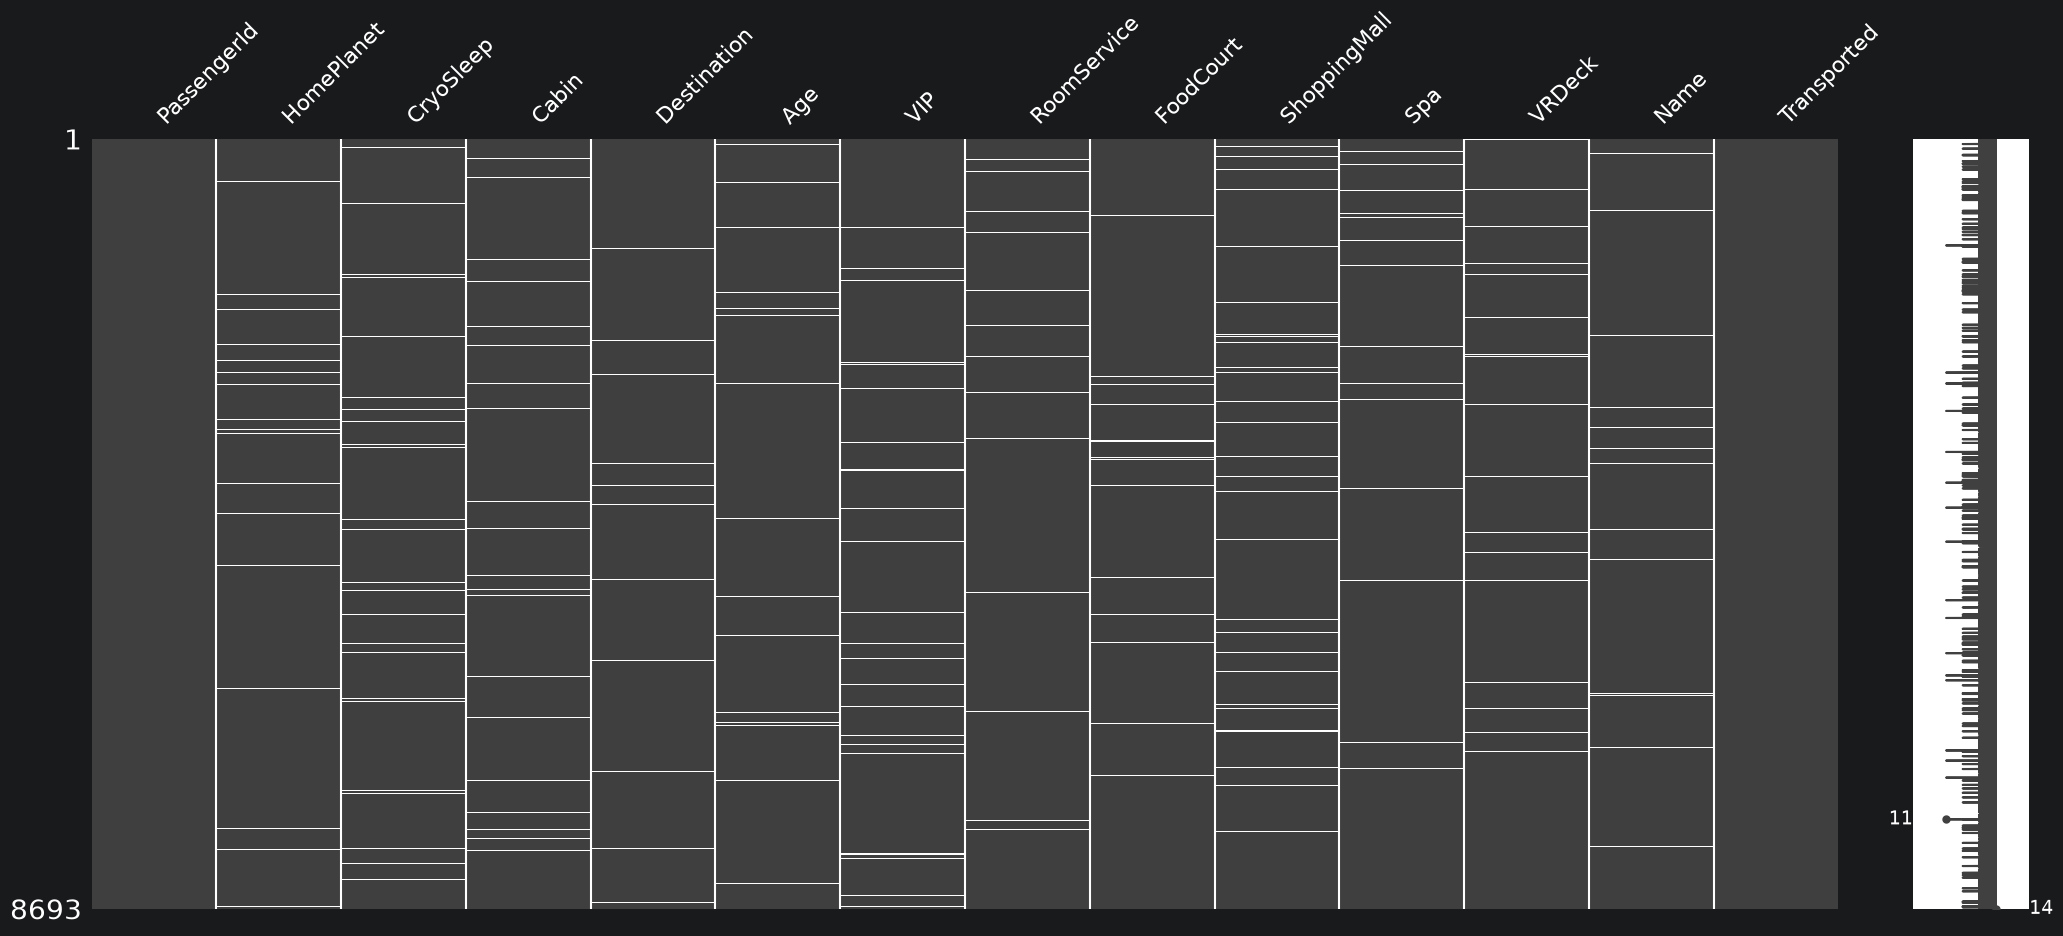

In [77]:
missingno.matrix(train)

<Axes: >

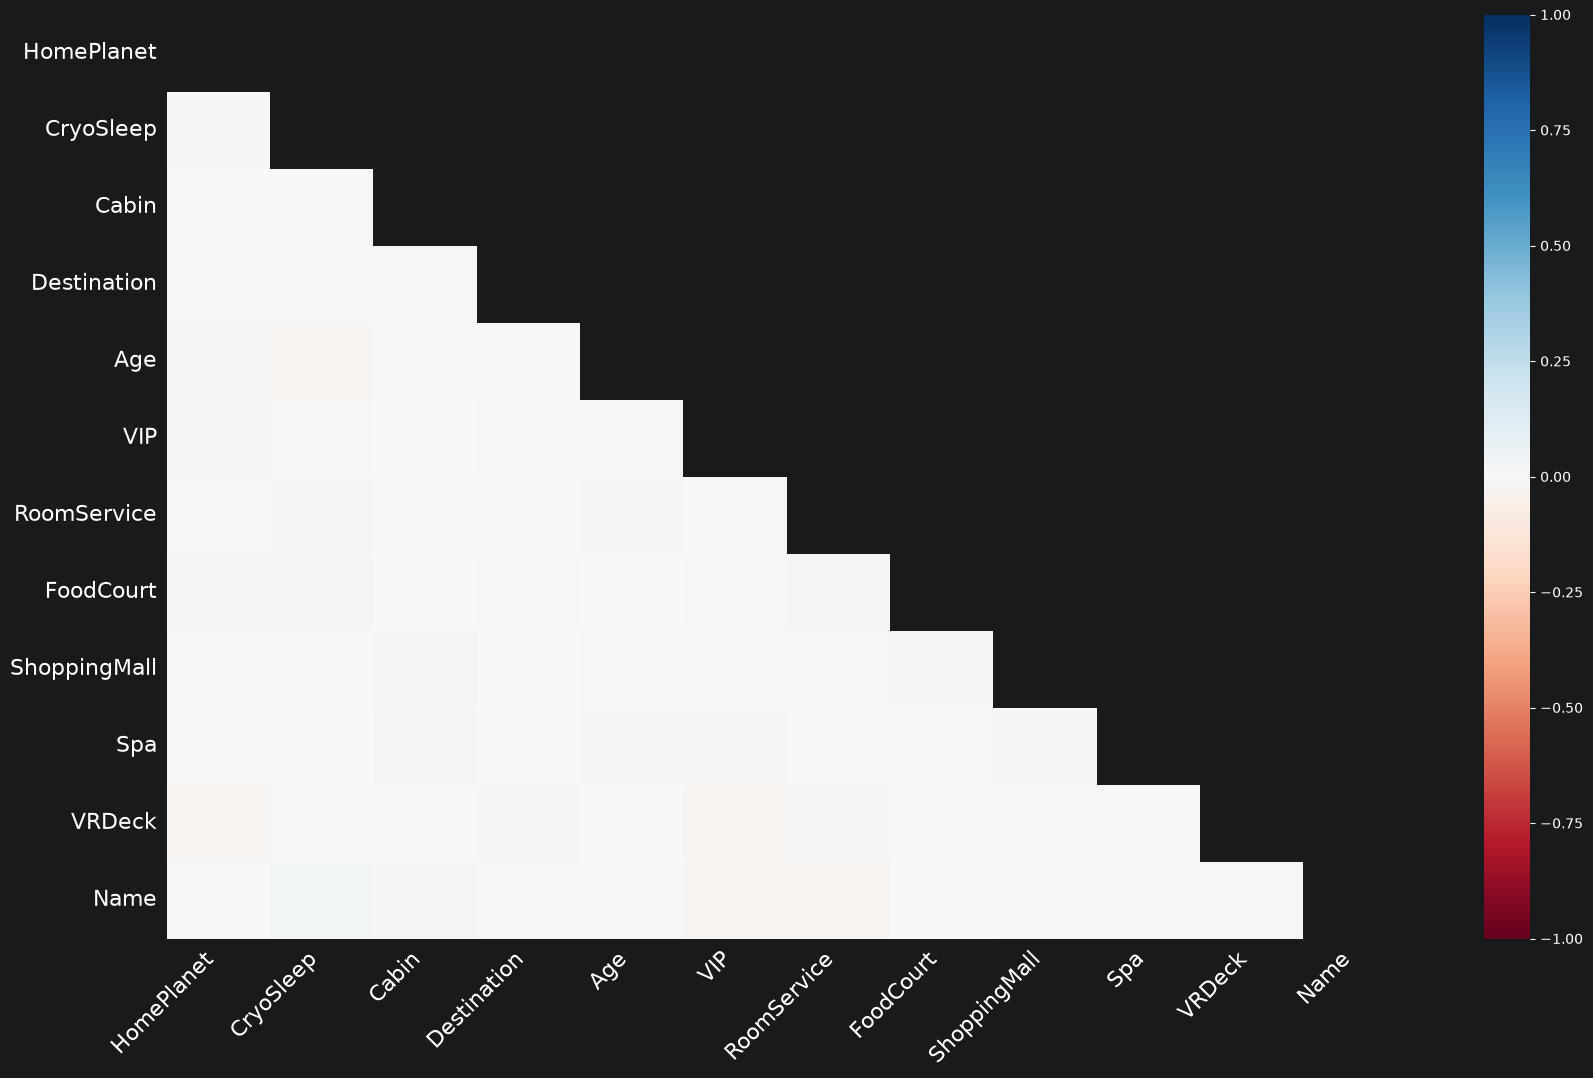

In [78]:
missingno.heatmap(train)

In [79]:
def engineer_features(df):
    df = df.copy()

    df[['Group', 'GroupMember']] = df['PassengerId'].str.split('_', expand=True)
    df['Group'] = df['Group'].astype(int)
    df['GroupMember'] = df['GroupMember'].astype(int)

    df['GroupSize'] = df.groupby('Group')['Group'].transform('count')
    df['IsAlone'] = (df['GroupSize'] == 1)

    cabin_split = df['Cabin'].str.split('/', expand=True)
    df['Deck'] = cabin_split[0]
    df['CabinNum'] = pd.to_numeric(cabin_split[1], errors='coerce')
    df['Side'] = cabin_split[2]

    df['Surname'] = df['Name'].str.split(' ').str[-1]

    spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df['TotalSpending'] = df[spending_cols].sum(axis=1, skipna=True)
    df['HasSpent'] = df['TotalSpending'] > 0

    return df, spending_cols


train, spending_cols = engineer_features(train)

In [80]:
def check_surname_consistency(df):
    group_surnames = df.dropna(subset=['Surname']).groupby('Group')['Surname'].nunique()
    inconsistent_groups = group_surnames[group_surnames > 1]
    print(f"Групп с несколькими фамилиями: {len(inconsistent_groups)} из {df['Group'].nunique()}")

check_surname_consistency(train)

Групп с несколькими фамилиями: 249 из 6217


In [81]:
cryo_spending_check = train.groupby('CryoSleep')['TotalSpending'].describe()
print(cryo_spending_check)

inconsistent_cryo = train[(train['CryoSleep'] == True) & (train['TotalSpending'] > 0)]
print(f"\nНесостыковок CryoSleep=True при spending > 0: {len(inconsistent_cryo)}")

            count         mean          std  min    25%     50%     75%  \
CryoSleep                                                                 
False      5439.0  2248.299687  3245.061489  0.0  746.0  1019.0  2416.0   
True       3037.0     0.000000     0.000000  0.0    0.0     0.0     0.0   

               max  
CryoSleep           
False      35987.0  
True           0.0  

Несостыковок CryoSleep=True при spending > 0: 0


In [82]:
def impute_missing(df, spending_cols):
    df = df.copy()

    group_home_planet = df.groupby('Group')['HomePlanet'].agg(
        lambda x: x.mode()[0] if not x.mode().empty else np.nan
    )
    df['HomePlanet'] = df['HomePlanet'].fillna(df['Group'].map(group_home_planet))

    surname_home_planet = df.dropna(subset=['Surname', 'HomePlanet']).groupby('Surname')['HomePlanet'].agg(
        lambda x: x.mode()[0] if not x.mode().empty else np.nan
    )
    mask = df['HomePlanet'].isna()
    df.loc[mask, 'HomePlanet'] = df.loc[mask, 'Surname'].map(surname_home_planet)

    group_deck = df.groupby('Group')['Deck'].agg(
        lambda x: x.mode()[0] if not x.mode().empty else np.nan
    )
    group_side = df.groupby('Group')['Side'].agg(
        lambda x: x.mode()[0] if not x.mode().empty else np.nan
    )
    df['Deck'] = df['Deck'].fillna(df['Group'].map(group_deck))
    df['Side'] = df['Side'].fillna(df['Group'].map(group_side))

    mask = df['CryoSleep'].isna()
    df.loc[mask, 'CryoSleep'] = df.loc[mask, 'TotalSpending'] == 0

    for col in spending_cols:
        mask = df[col].isna() & (df['CryoSleep'] == True)
        df.loc[mask, col] = 0

    return df

train = impute_missing(train, spending_cols)

In [83]:
X = train.drop(columns=["Transported", "PassengerId", "Name", "Cabin", "Surname", "Group"])
y = train["Transported"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "str", "bool"]).columns

In [84]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

categorical_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_dense = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer_dense, cat_cols)
])

In [85]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [86]:
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

baseline_pipeline.fit(X_train, y_train)
baseline_preds = baseline_pipeline.predict(X_val)

print(f"Baseline accuracy: {accuracy_score(y_val, baseline_preds):.4f}")

Baseline accuracy: 0.7907


In [87]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'NaiveBayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'LDA': LinearDiscriminantAnalysis(),
}

dense_required = {'NaiveBayes', 'LDA'}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    prep = preprocessor_dense if name in dense_required else preprocessor
    pipeline = Pipeline(steps=[
        ("preprocessor", prep),
        ("model", model)
    ])
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

LogisticRegression: 0.7909 ± 0.0052
SVM: 0.7982 ± 0.0070
DecisionTree: 0.7482 ± 0.0057
RandomForest: 0.8039 ± 0.0090
XGBoost: 0.8038 ± 0.0058
NaiveBayes: 0.7453 ± 0.0464
KNN: 0.7734 ± 0.0118
LDA: 0.7758 ± 0.0082


In [88]:
results_list = []

In [89]:
logreg_param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['saga'],
    'model__l1_ratio': [0.0, 1.0]  # 0.0 заменяет penalty='l2', 1.0 заменяет penalty='l1'
}

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_grid = GridSearchCV(
    logreg_pipeline, param_grid=logreg_param_grid,
    scoring='accuracy', cv=cv, n_jobs=-1, verbose=1
)
logreg_grid.fit(X_train, y_train)

print(f"LogisticRegression best params: {logreg_grid.best_params_}")
print(f"LogisticRegression best CV accuracy: {logreg_grid.best_score_:.4f}")

results_list.append({
    'model': 'LogisticRegression',
    'best_params': logreg_grid.best_params_,
    'cv_accuracy': logreg_grid.best_score_
})

Fitting 5 folds for each of 10 candidates, totalling 50 fits
LogisticRegression best params: {'model__C': 0.1, 'model__l1_ratio': 0.0, 'model__solver': 'saga'}
LogisticRegression best CV accuracy: 0.7915


In [90]:
svm_param_dist = {
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'model__kernel': ['rbf', 'linear'],
}

svm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(random_state=42))
])

svm_random = RandomizedSearchCV(
    svm_pipeline, param_distributions=svm_param_dist,
    n_iter=20, scoring='accuracy', cv=cv, n_jobs=-1, random_state=42, verbose=1
)
svm_random.fit(X_train, y_train)

print(f"SVM best params: {svm_random.best_params_}")
print(f"SVM best CV accuracy: {svm_random.best_score_:.4f}")

results_list.append({
    'model': 'SVM',
    'best_params': svm_random.best_params_,
    'cv_accuracy': svm_random.best_score_
})

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM best params: {'model__kernel': 'rbf', 'model__gamma': 0.01, 'model__C': 10}
SVM best CV accuracy: 0.7939


In [91]:
dt_param_grid = {
    'model__max_depth': [3, 5, 7, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__criterion': ['gini', 'entropy'],
}

dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_grid = GridSearchCV(
    dt_pipeline, param_grid=dt_param_grid,
    scoring='accuracy', cv=cv, n_jobs=-1, verbose=1
)
dt_grid.fit(X_train, y_train)

print(f"DecisionTree best params: {dt_grid.best_params_}")
print(f"DecisionTree best CV accuracy: {dt_grid.best_score_:.4f}")

results_list.append({
    'model': 'DecisionTree',
    'best_params': dt_grid.best_params_,
    'cv_accuracy': dt_grid.best_score_
})

Fitting 5 folds for each of 90 candidates, totalling 450 fits
DecisionTree best params: {'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10}
DecisionTree best CV accuracy: 0.7854


In [92]:
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
}

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

rf_grid = GridSearchCV(
    rf_pipeline, param_grid=rf_param_grid,
    scoring='accuracy', cv=cv, n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)

print(f"RandomForest best params: {rf_grid.best_params_}")
print(f"RandomForest best CV accuracy: {rf_grid.best_score_:.4f}")

results_list.append({
    'model': 'RandomForest',
    'best_params': rf_grid.best_params_,
    'cv_accuracy': rf_grid.best_score_
})

Fitting 5 folds for each of 108 candidates, totalling 540 fits
RandomForest best params: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 200}
RandomForest best CV accuracy: 0.8008


In [93]:
xgb_param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [3, 4, 5, 6, 7, 8],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'model__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
}

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(random_state=42, eval_metric='logloss'))
])

xgb_random = RandomizedSearchCV(
    xgb_pipeline, param_distributions=xgb_param_dist,
    n_iter=50, scoring='accuracy', cv=cv, n_jobs=-1, random_state=42, verbose=1
)
xgb_random.fit(X_train, y_train)

print(f"XGBoost best params: {xgb_random.best_params_}")
print(f"XGBoost best CV accuracy: {xgb_random.best_score_:.4f}")

results_list.append({
    'model': 'XGBoost',
    'best_params': xgb_random.best_params_,
    'cv_accuracy': xgb_random.best_score_
})

Fitting 5 folds for each of 50 candidates, totalling 250 fits
XGBoost best params: {'model__subsample': 0.9, 'model__n_estimators': 100, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}
XGBoost best CV accuracy: 0.8095


In [94]:
results_df = pd.DataFrame(results_list).sort_values('cv_accuracy', ascending=False).reset_index(drop=True)
results_df

,model,best_params,cv_accuracy
0,XGBoost,"{'model__subsample': 0.9, 'model__n_estimators...",0.809463
1,RandomForest,"{'model__max_depth': 10, 'model__min_samples_l...",0.800835
2,SVM,"{'model__kernel': 'rbf', 'model__gamma': 0.01,...",0.793933
3,LogisticRegression,"{'model__C': 0.1, 'model__l1_ratio': 0.0, 'mod...",0.791487
4,DecisionTree,"{'model__criterion': 'entropy', 'model__max_de...",0.785446


In [95]:
final_pipeline = xgb_random.best_estimator_
final_pipeline.fit(X, y)

test = pd.read_csv("data/test.csv")
test, _ = engineer_features(test)
test = impute_missing(test, spending_cols)

test_ids = test["PassengerId"]
X_test = test.drop(columns=["PassengerId", "Name", "Cabin", "Surname", "Group"])

test_preds = final_pipeline.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Transported": test_preds.astype(bool)
})
submission.to_csv("submission.csv", index=False)